In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plasma = pd.read_csv('test4.csv')
background = pd.read_csv('back7.csv')


In [3]:
plasma.head()

,Wavelength_nm,Intensity
0,317.779,0.001732
1,318.882,0.001568
2,319.985,0.001978
3,321.088,0.002151
4,322.191,0.002487


In [4]:
background.head()

,Wavelength_nm,Intensity
0,317.779,0.000319
1,318.882,0.000409
2,319.985,0.000672
3,321.088,0.001171
4,322.191,0.001056


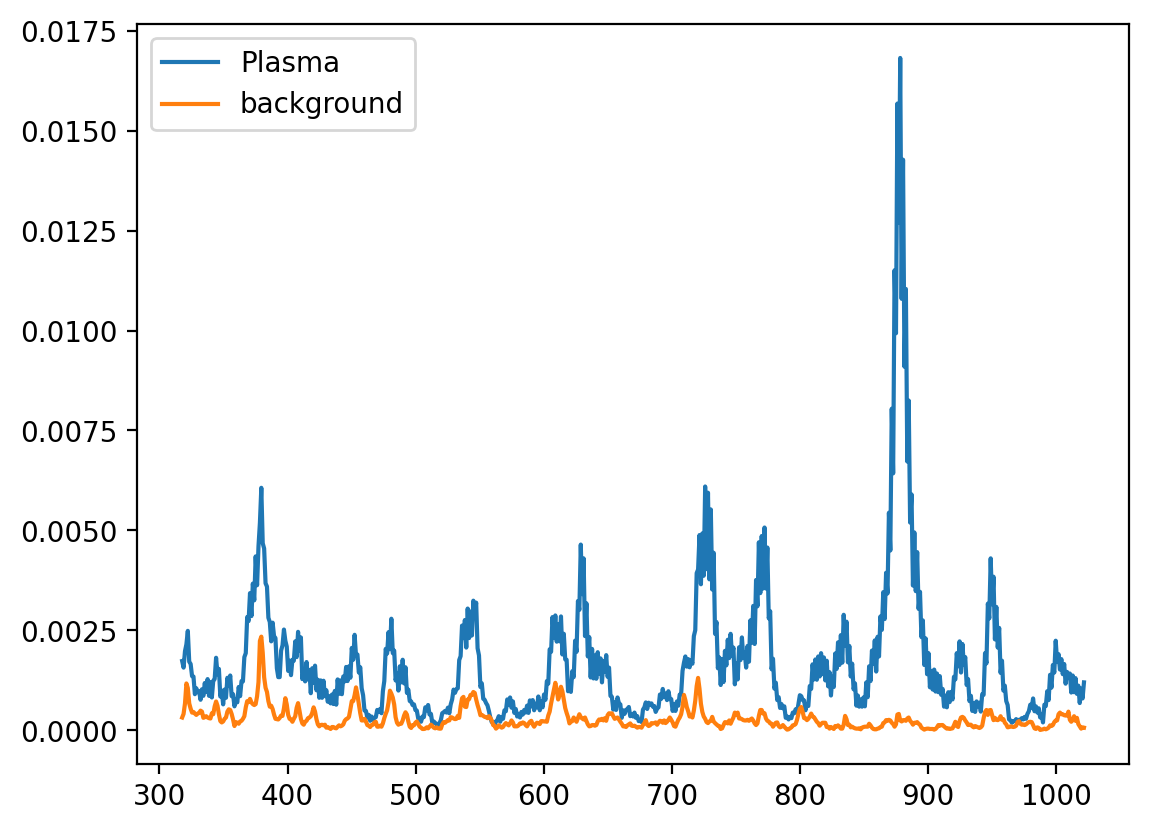

In [6]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], plasma['Intensity'], label='Plasma')
plt.plot(background['Wavelength_nm'], background['Intensity'], label='background')
plt.legend()

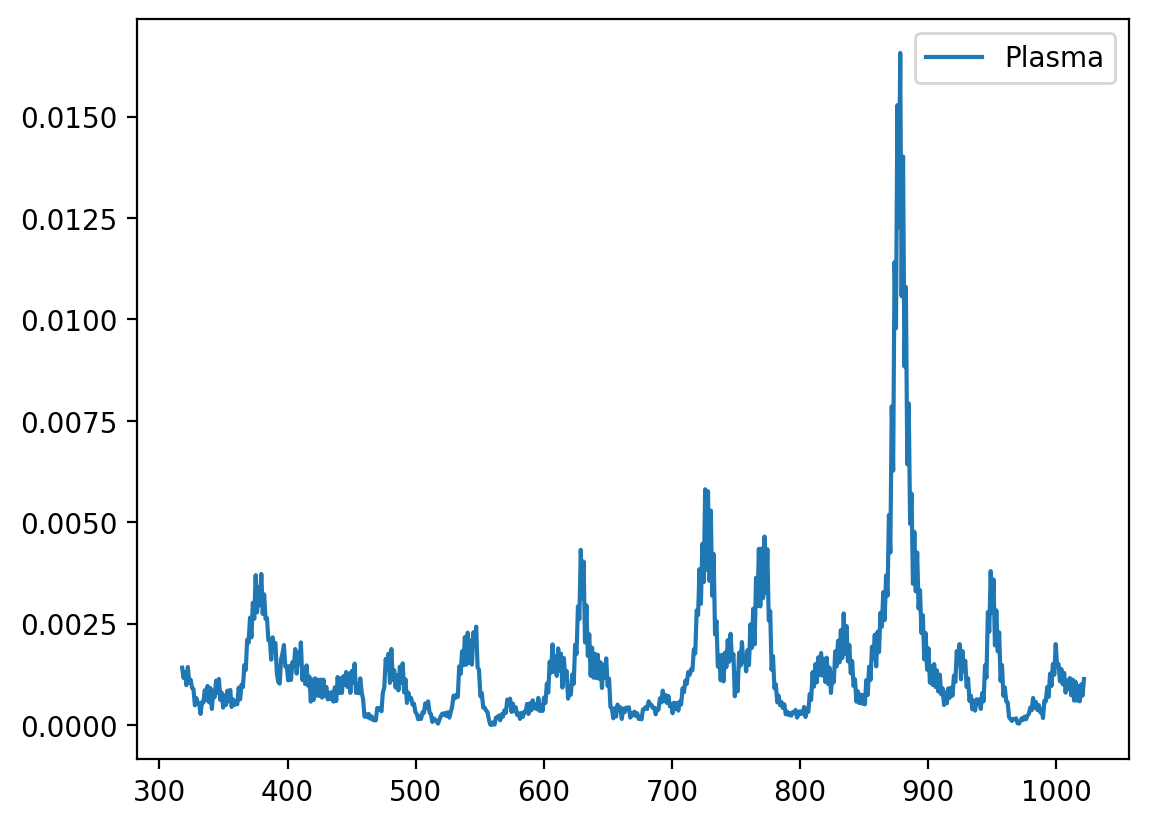

In [8]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], (plasma['Intensity']-background['Intensity']).clip(lower=0), label='Plasma')
plt.legend()

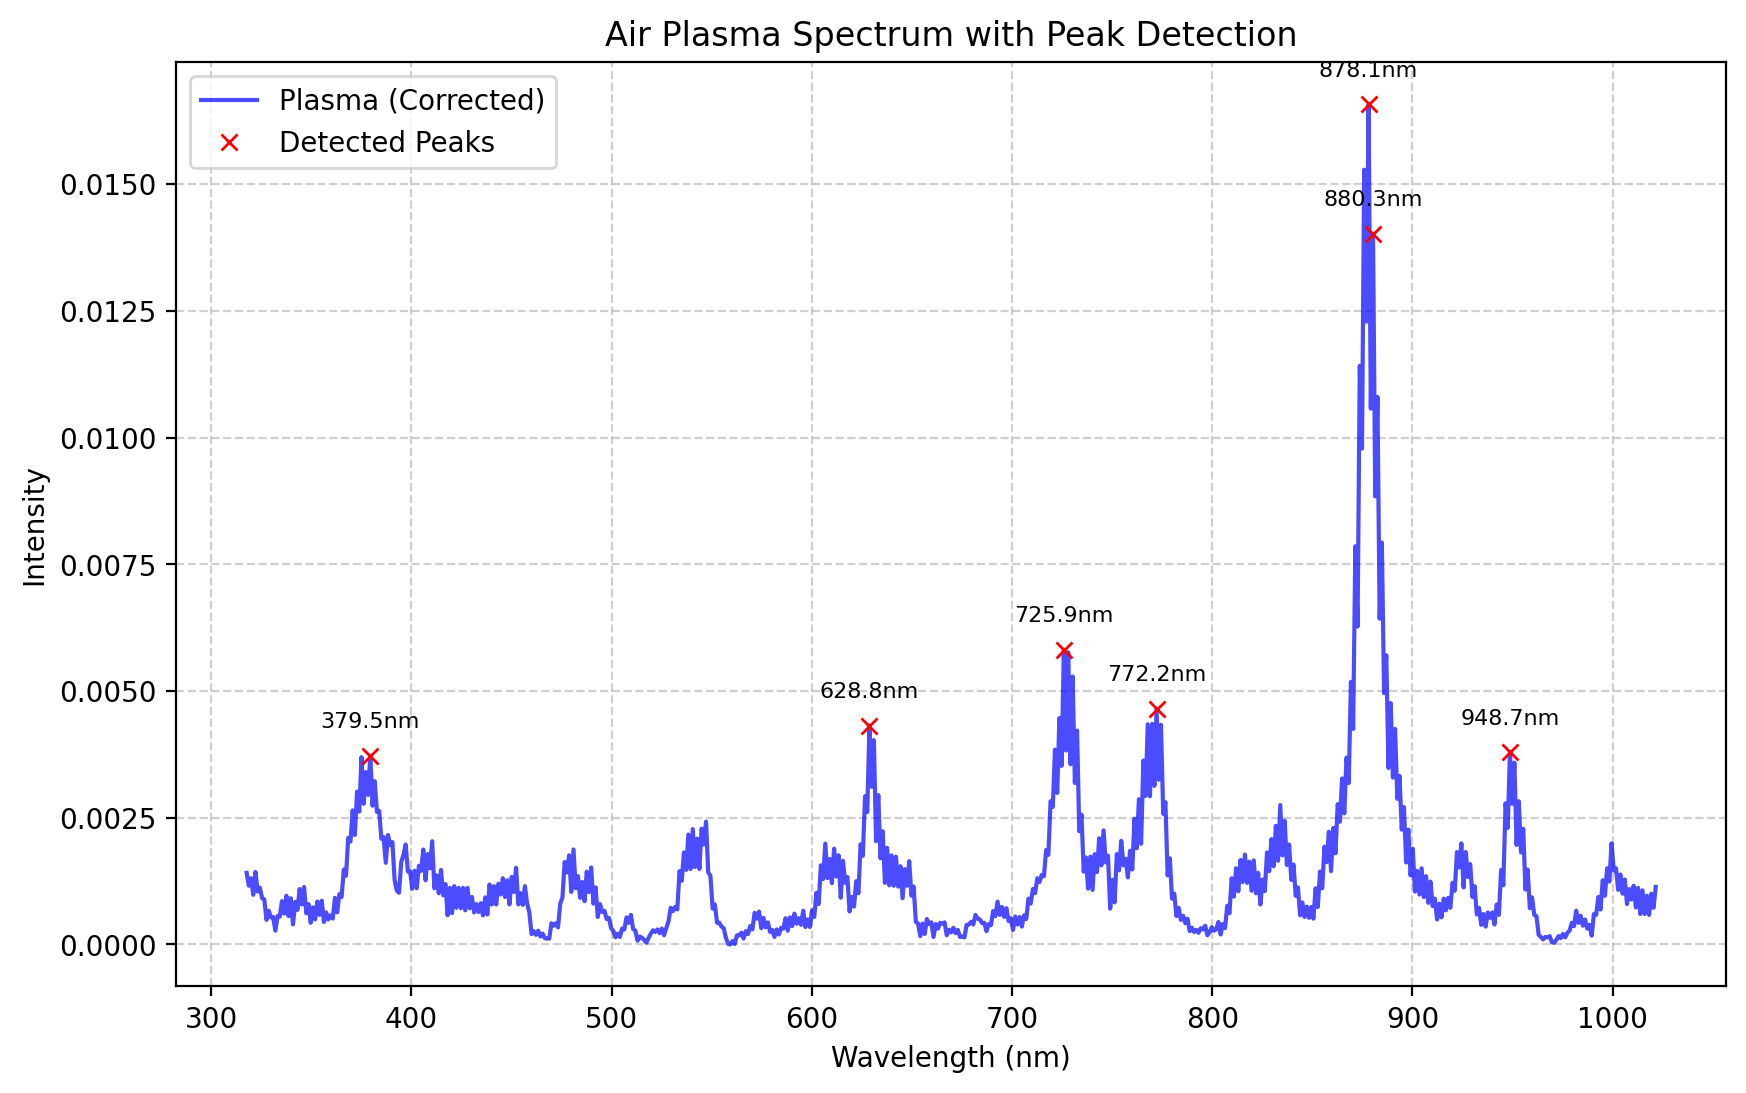

In [27]:
from scipy.signal import find_peaks,peak_widths

# 1. Calculate the corrected intensity
# We clip at 0 because negative intensity values (noise) don't represent a signal
corrected_intensity = (plasma['Intensity'] - background['Intensity']).clip(lower=0)
wavelengths = plasma['Wavelength_nm']

# 2. Find the peaks
# 'prominence' is key: it ignores small ripples/noise. 
# Adjust 'prominence' based on your signal-to-noise ratio.
peaks, properties = find_peaks(corrected_intensity, prominence = 0.003)

# 3. Plotting
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(wavelengths, corrected_intensity, label='Plasma (Corrected)', color='blue', alpha=0.7)

# Plot the identified peaks
plt.plot(wavelengths.iloc[peaks], corrected_intensity.iloc[peaks], "x", color='red', label='Detected Peaks')

# Optional: Annotate the peaks with their wavelength
for i in peaks:
    plt.annotate(f"{wavelengths.iloc[i]:.1f}nm", 
                 (wavelengths.iloc[i], corrected_intensity.iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Air Plasma Spectrum with Peak Detection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [36]:


def analyze_specific_peaks(df, targets, window=15):
    """
    Finds specific peaks, returns heights and FWHM in nm.
    """
    wavelengths = df['Wavelength_nm'].values
    intensity = (df['Intensity'] - background['Intensity']).clip(lower=0).values
    prominence = max(intensity)*0.1
    
    nm_per_pixel = np.mean(np.diff(wavelengths))

    peaks, props = find_peaks(intensity, prominence=prominence)

    widths_indices = peak_widths(intensity, peaks, rel_height=0.5)[0]

    results = []

    for target in targets:
        diffs = np.abs(wavelengths[peaks] - target)
        closest_idx = np.argmin(diffs)
        
        if diffs[closest_idx] <= window:
            p_idx = peaks[closest_idx]
            actual_wl = wavelengths[p_idx]
            height = intensity[p_idx]
            
            fwhm_nm = widths_indices[closest_idx] * nm_per_pixel


            results.append({
                "Target_nm": target,
                "Actual_nm": actual_wl,
                "Height": height,
                "FWHM_nm": fwhm_nm
            })
        else:
            results.append({
                "Target_nm": target,
                "Actual_nm": "Not Found",
                "Height": 0,
                "FWHM_nm": 0
            })

    return pd.DataFrame(results)

target_list = [380,481,630,725,770, 880, 950]
peak_data = analyze_specific_peaks(plasma, target_list)

print(peak_data)

def peak_ratios(peak_data):
    pk1 = peak_data.loc[peak_data['Target_nm'] == 380, 'Height'].values[0]
    pk2 = peak_data.loc[peak_data['Target_nm'] == 481, 'Height'].values[0]
    pk3 = peak_data.loc[peak_data['Target_nm'] == 630, 'Height'].values[0]
    pk4 = peak_data.loc[peak_data['Target_nm'] == 725, 'Height'].values[0]
    pk5 = peak_data.loc[peak_data['Target_nm'] == 770, 'Height'].values[0]
    pk6 = peak_data.loc[peak_data['Target_nm'] == 880, 'Height'].values[0]
    pk7 = peak_data.loc[peak_data['Target_nm'] == 950, 'Height'].values[0]
    ratio1 = pk5 / pk1 if pk1 != 0 else np.nan
    ratio2 = pk6/pk2 if pk2 != 0 else np.nan
    ratio3 = pk2/pk1 if pk1 != 0 else np.nan
    ratio4 = pk5/pk4 if pk3 != 0 else np.nan
    ratio5= pk7/pk3 if pk3 != 0 else np.nan
    return {
        "r1": ratio1,
        "r2": ratio2,
        "r3": ratio3,
        "r4": ratio4,
        "r5": ratio5
    }

ratios = peak_ratios(peak_data)
print(ratios)

   Target_nm  Actual_nm    Height    FWHM_nm
0        380    379.547  0.003724  18.065879
1        481    481.023  0.001874   8.527351
2        630    628.825  0.004318   6.060377
3        725    725.889  0.005812  10.600562
4        770    772.215  0.004647  10.504147
5        880    880.309  0.014021   0.918592
6        950    948.695  0.003794   5.924316
{'r1': np.float64(1.2478932313803812), 'r2': np.float64(7.4830504586058675), 'r3': np.float64(0.5031484532617266), 'r4': np.float64(0.7995133765712127), 'r5': np.float64(0.8784447244227875)}
